<a href="https://colab.research.google.com/github/Pranayshukla0610/Transformers/blob/main/Transformer_Gen_AI_King_Queen_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import math
import random
import matplotlib.pyplot as plt

In [2]:
print(torch.__version__)

2.11.0+cpu


In [3]:
device = torch.device('cpu')
print("Device:",device)

Device: cpu


In [4]:
text = """
the king was happy because the kingdom was peaceful.
the queen was kind and the people loved the queen.
the prince was young and the prince wanted to become a great king.
the kingdom was beautiful and the people were happy.
the king and the queen lived in a beautiful castle.
the prince learned many things from the king.
the people trusted the king because the king was kind.
"""

In [5]:
text = text*100

In [6]:
print(text[:500])
print("Characters:",len(text))


the king was happy because the kingdom was peaceful.
the queen was kind and the people loved the queen.
the prince was young and the prince wanted to become a great king.
the kingdom was beautiful and the people were happy.
the king and the queen lived in a beautiful castle.
the prince learned many things from the king.
the people trusted the king because the king was kind.

the king was happy because the kingdom was peaceful.
the queen was kind and the people loved the queen.
the prince was yo
Characters: 37800


In [7]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("Vocabulary Size:",vocab_size)
print(chars)

Vocabulary Size: 26
['\n', ' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'y']


In [8]:
stoi = {ch: i for i, ch in enumerate(chars)}

In [9]:
print(stoi['a'])
print(stoi[' '])

3
1


In [11]:
itos = {i: ch for i, ch in enumerate(chars)}

In [12]:
def encode(text):
  return [stoi[ch] for ch in text]

In [13]:
encoded = encode("the king")
print(encoded)

[21, 10, 7, 1, 12, 11, 15, 9]


In [14]:
def decode(numbers):
  return ''.join(itos[i] for i in numbers)

In [15]:
print(decode(encoded))

the king


In [16]:
data = torch.tensor(
    encode(text),
    dtype=torch.long
)
print(data.shape)

torch.Size([37800])


In [17]:
n = int(0.9 * len(data))

train_data = data[:n]
val_data = data[n:]

print("Training:",len(train_data))
print("Validation:",len(val_data))

Training: 34020
Validation: 3780


In [18]:
block_size = 64

In [19]:
batch_size = 32

def get_batch(split):

    dataset = train_data if split == "train" else val_data

    ix = torch.randint(
        len(dataset) - block_size,
        (batch_size,)
    )

    x = torch.stack([
        dataset[i:i + block_size]
        for i in ix
    ])

    y = torch.stack([
        dataset[i + 1:i + block_size + 1]
        for i in ix
    ])

    return x.to(device), y.to(device)

In [20]:
X, Y = get_batch("train")

print("X:", X.shape)
print("Y:", Y.shape)

X: torch.Size([32, 64])
Y: torch.Size([32, 64])


In [21]:
embedding_dim = 64
token_embedding = nn.Embedding(
    vocab_size,
    embedding_dim
)

In [22]:
X, Y = get_batch("train")

embeddings = token_embedding(X)

print(embeddings.shape)

torch.Size([32, 64, 64])


In [23]:
position_embedding = nn.Embedding(
    block_size,
    embedding_dim
)

In [24]:
positions = torch.arange(
    block_size,
    device=device
)

print(positions)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63])


In [25]:
pos_embeddings = position_embedding(positions)

print(pos_embeddings.shape)

torch.Size([64, 64])


In [28]:
x = token_embedding(X)

positions = torch.arange(
    block_size,
    device=device
)

x = x + position_embedding(positions)

In [29]:
class SelfAttentionHead(nn.Module):

    def __init__(self, embedding_dim, head_size):
        super().__init__()

        self.key = nn.Linear(
            embedding_dim,
            head_size,
            bias=False
        )

        self.query = nn.Linear(
            embedding_dim,
            head_size,
            bias=False
        )

        self.value = nn.Linear(
            embedding_dim,
            head_size,
            bias=False
        )

    def forward(self, x):

        B, T, C = x.shape

        k = self.key(x)

        q = self.query(x)

        v = self.value(x)

        attention_scores = (
            q @ k.transpose(-2, -1)
        ) / math.sqrt(k.shape[-1])

        return attention_scores

In [30]:
head = SelfAttentionHead(
    embedding_dim=64,
    head_size=16
)

scores = head(x)

print(scores.shape)

torch.Size([32, 64, 64])


In [31]:
class SelfAttentionHead(nn.Module):

    def __init__(self, embedding_dim, head_size):
        super().__init__()

        self.key = nn.Linear(
            embedding_dim,
            head_size,
            bias=False
        )

        self.query = nn.Linear(
            embedding_dim,
            head_size,
            bias=False
        )

        self.value = nn.Linear(
            embedding_dim,
            head_size,
            bias=False
        )

        self.register_buffer(
            "tril",
            torch.tril(
                torch.ones(block_size, block_size)
            )
        )

    def forward(self, x):

        B, T, C = x.shape

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        scores = (
            q @ k.transpose(-2, -1)
        ) / math.sqrt(k.shape[-1])

        scores = scores.masked_fill(
            self.tril[:T, :T] == 0,
            float("-inf")
        )

        attention_weights = F.softmax(
            scores,
            dim=-1
        )

        output = attention_weights @ v

        return output

In [32]:
class MultiHeadAttention(nn.Module):

    def __init__(
        self,
        embedding_dim,
        num_heads,
        head_size
    ):
        super().__init__()

        self.heads = nn.ModuleList([
            SelfAttentionHead(
                embedding_dim,
                head_size
            )
            for _ in range(num_heads)
        ])

        self.projection = nn.Linear(
            num_heads * head_size,
            embedding_dim
        )

    def forward(self, x):

        out = torch.cat(
            [head(x) for head in self.heads],
            dim=-1
        )

        return self.projection(out)

In [33]:
num_heads = 4
head_size = embedding_dim // num_heads

In [34]:
attention = MultiHeadAttention(
    embedding_dim=64,
    num_heads=4,
    head_size=16
)

In [35]:
attention_output = attention(x)

print(attention_output.shape)

torch.Size([32, 64, 64])


In [36]:
class FeedForward(nn.Module):

    def __init__(self, embedding_dim):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                embedding_dim,
                4 * embedding_dim
            ),

            nn.ReLU(),

            nn.Linear(
                4 * embedding_dim,
                embedding_dim
            )
        )

    def forward(self, x):

        return self.network(x)

In [37]:
nn.LayerNorm(embedding_dim)

LayerNorm((64,), eps=1e-05, elementwise_affine=True)

In [38]:
class TransformerBlock(nn.Module):

    def __init__(
        self,
        embedding_dim,
        num_heads
    ):
        super().__init__()

        head_size = embedding_dim // num_heads

        self.attention = MultiHeadAttention(
            embedding_dim,
            num_heads,
            head_size
        )

        self.feed_forward = FeedForward(
            embedding_dim
        )

        self.ln1 = nn.LayerNorm(
            embedding_dim
        )

        self.ln2 = nn.LayerNorm(
            embedding_dim
        )

    def forward(self, x):

        x = x + self.attention(
            self.ln1(x)
        )

        x = x + self.feed_forward(
            self.ln2(x)
        )

        return x

In [39]:
num_layers = 2

In [40]:
class MiniGPT(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        block_size,
        num_heads,
        num_layers
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.position_embedding = nn.Embedding(
            block_size,
            embedding_dim
        )

        self.blocks = nn.Sequential(*[
            TransformerBlock(
                embedding_dim,
                num_heads
            )
            for _ in range(num_layers)
        ])

        self.ln_final = nn.LayerNorm(
            embedding_dim
        )

        self.lm_head = nn.Linear(
            embedding_dim,
            vocab_size
        )

In [41]:
    def forward(self, idx, targets=None):

        B, T = idx.shape

        token_emb = self.token_embedding(idx)

        positions = torch.arange(
            T,
            device=idx.device
        )

        position_emb = self.position_embedding(
            positions
        )

        x = token_emb + position_emb

        x = self.blocks(x)

        x = self.ln_final(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:

            B, T, C = logits.shape

            logits_flat = logits.view(
                B * T,
                C
            )

            targets_flat = targets.view(
                B * T
            )

            loss = F.cross_entropy(
                logits_flat,
                targets_flat
            )

        return logits, loss

In [42]:
class MiniGPT(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        block_size,
        num_heads,
        num_layers
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.position_embedding = nn.Embedding(
            block_size,
            embedding_dim
        )

        self.blocks = nn.Sequential(*[
            TransformerBlock(
                embedding_dim,
                num_heads
            )
            for _ in range(num_layers)
        ])

        self.ln_final = nn.LayerNorm(
            embedding_dim
        )

        self.lm_head = nn.Linear(
            embedding_dim,
            vocab_size
        )

    def forward(self, idx, targets=None):

        B, T = idx.shape

        token_emb = self.token_embedding(idx)

        positions = torch.arange(
            T,
            device=idx.device
        )

        position_emb = self.position_embedding(
            positions
        )

        x = token_emb + position_emb

        x = self.blocks(x)

        x = self.ln_final(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:

            B, T, C = logits.shape

            logits_flat = logits.reshape(
                B * T,
                C
            )

            targets_flat = targets.reshape(
                B * T
            )

            loss = F.cross_entropy(
                logits_flat,
                targets_flat
            )

        return logits, loss

In [44]:
model = MiniGPT(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    block_size=block_size,
    num_heads=num_heads,
    num_layers=num_layers
).to(device)

In [45]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parameters: {total_params:,}"
)

Parameters: 107,162


In [46]:
X, Y = get_batch("train")

logits, loss = model(X, Y)

print("Logits:", logits.shape)
print("Loss:", loss.item())

Logits: torch.Size([32, 64, 26])
Loss: 3.448826313018799


In [47]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4
)

In [48]:
max_iters = 3000
eval_interval = 300

In [49]:
@torch.no_grad()
def estimate_loss():

    model.eval()

    losses = {}

    for split in ["train", "val"]:

        split_losses = []

        for _ in range(50):

            X, Y = get_batch(split)

            logits, loss = model(X, Y)

            split_losses.append(
                loss.item()
            )

        losses[split] = np.mean(
            split_losses
        )

    model.train()

    return losses

In [50]:
train_losses = []
val_losses = []

for step in range(max_iters):

    if step % eval_interval == 0:

        losses = estimate_loss()

        train_losses.append(
            losses["train"]
        )

        val_losses.append(
            losses["val"]
        )

        print(
            f"Step {step}: "
            f"train loss = {losses['train']:.4f}, "
            f"val loss = {losses['val']:.4f}"
        )

    X, Y = get_batch("train")

    logits, loss = model(X, Y)

    optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    optimizer.step()

Step 0: train loss = 3.4620, val loss = 3.4617
Step 300: train loss = 1.2437, val loss = 1.2482
Step 600: train loss = 0.5736, val loss = 0.5723
Step 900: train loss = 0.2018, val loss = 0.2039
Step 1200: train loss = 0.0989, val loss = 0.0992
Step 1500: train loss = 0.0726, val loss = 0.0725
Step 1800: train loss = 0.0638, val loss = 0.0643
Step 2100: train loss = 0.0597, val loss = 0.0600
Step 2400: train loss = 0.0569, val loss = 0.0563
Step 2700: train loss = 0.0546, val loss = 0.0545


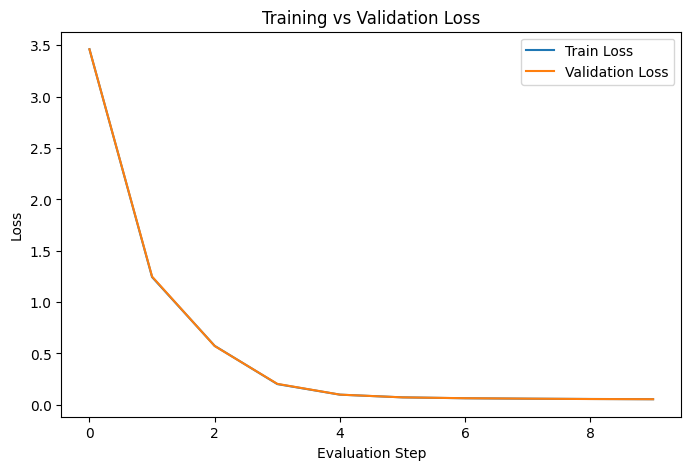

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [52]:
@torch.no_grad()
def generate(
    model,
    idx,
    max_new_tokens,
    temperature=1.0
):

    model.eval()

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -model.block_size:]

        logits, _ = model(idx_cond)

        logits = logits[:, -1, :]

        logits = logits / temperature

        probabilities = F.softmax(
            logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        idx = torch.cat(
            (idx, next_token),
            dim=1
        )

    return idx

In [53]:
prompt = "the king"

In [54]:
context = torch.tensor(
    [encode(prompt)],
    dtype=torch.long,
    device=device
)

In [55]:
generated = generate(
    model,
    context,
    max_new_tokens=300,
    temperature=0.8
)

In [56]:
result = decode(
    generated[0].tolist()
)

print(result)

the king was happy because the kingdom was peaceful.
the queen was kind and the people loved the queen.
the prince was young and the prince wanted to become a great king.
the kingdom was beautiful and the people were happy.
the king and the queen lived in a beautiful castle.
the prince learned many things f


In [57]:
@torch.no_grad()
def generate_top_k(
    model,
    idx,
    max_new_tokens,
    temperature=1.0,
    top_k=5
):

    model.eval()

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -model.block_size:]

        logits, _ = model(idx_cond)

        logits = logits[:, -1, :]

        logits = logits / temperature

        values, indices = torch.topk(
            logits,
            min(top_k, logits.size(-1))
        )

        filtered_logits = torch.full_like(
            logits,
            float("-inf")
        )

        filtered_logits.scatter_(
            1,
            indices,
            values
        )

        probabilities = F.softmax(
            filtered_logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        idx = torch.cat(
            (idx, next_token),
            dim=1
        )

    return idx

In [58]:
prompt = "the king"

context = torch.tensor(
    [encode(prompt)],
    dtype=torch.long
).to(device)

generated = generate_top_k(
    model,
    context,
    max_new_tokens=300,
    temperature=0.8,
    top_k=5
)

print(
    decode(
        generated[0].tolist()
    )
)

the kingdom was beautiful and the people were happy.
the king and the queen lived in a beautiful castle.
the prince learned many things from the king.
the people trusted the king because the king was kind.

the king was happy because the kingdom was peaceful.
the queen was kind and the people loved the quee


In [59]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "vocab_size": vocab_size,
        "embedding_dim": embedding_dim,
        "block_size": block_size,
        "num_heads": num_heads,
        "num_layers": num_layers,
        "stoi": stoi,
        "itos": itos
    },
    "mini_gpt.pth"
)

In [60]:
checkpoint = torch.load(
    "mini_gpt.pth",
    map_location=device
)

In [61]:
loaded_model = MiniGPT(
    vocab_size=checkpoint["vocab_size"],
    embedding_dim=checkpoint["embedding_dim"],
    block_size=checkpoint["block_size"],
    num_heads=checkpoint["num_heads"],
    num_layers=checkpoint["num_layers"]
).to(device)

In [62]:
loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>